<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/star_sun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sun - Analysis**

In [1]:
!pip install sunpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 20.5 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma

import astropy.units as u

import sunpy.map
from sunpy.data.sample import AIA_171_IMAGE
from sunpy.map.maputils import all_coordinates_from_map

In [3]:
# Start with sample data
aia = sunpy.map.Map(AIA_171_IMAGE)

*Find and mask the brightest pixel*

In [4]:
# Find maximum in AIA image data then transform that pixel coordinate to a map coordinate
pixel_pos = np.argwhere(aia.data == aia.data.max()) * u.pixel
hpc_max = aia.wcs.pixel_to_world(pixel_pos[:, 1], pixel_pos[:, 0])

<Figure size 1000x800 with 0 Axes>

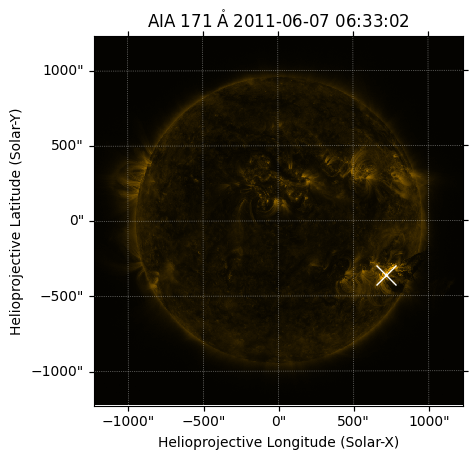

In [6]:
plt.figure(figsize=(10, 8))
fig = plt.figure()
ax = fig.add_subplot(projection=aia)
aia.plot(axes=ax)
ax.plot_coord(hpc_max, color='white', marker='x', markersize=15)
plt.show()

A utility function gives us access to the helioprojective coordinate of each pixels. We create a new array which contains the normalized radial position for each pixel adjusted for the position of the brightest pixel (using hpc_max) and then create a new map.

In [7]:
hpc_coords = all_coordinates_from_map(aia)
r_mask = np.sqrt((hpc_coords.Tx - hpc_max.Tx) ** 2 +
                 (hpc_coords.Ty - hpc_max.Ty) ** 2) / aia.rsun_obs
mask = ma.masked_less_equal(r_mask, 0.1)
scaled_map = sunpy.map.Map(aia.data, aia.meta, mask=mask.mask)

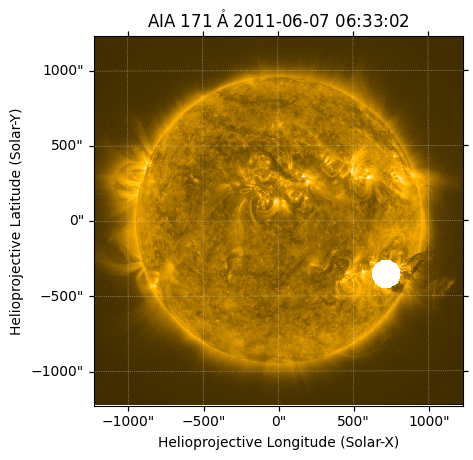

In [8]:
fig = plt.figure()
ax = fig.add_subplot(projection=scaled_map)
scaled_map.plot(axes=ax)
plt.show()